# Introduction

## Why Block Matching Falls Short

Block matching treats every pixel independently. It looks at each pixel in isolation and asks for the local best match. It has no notion of consistency — nothing stops it from assigning wildly different disparities to two neighboring pixels that are almost certainly part of the same flat surface. The result often looks noisy and fragmented.

Dynamic programming takes a completely different philosophy:
instead of matching one pixel at a time, it finds the globally optimal alignment of an entire scanline at once, respecting the natural order of pixels.

---

## Matching and Skipping:

In DP stereo, for each row, you have a left scanline Il and a right scanline Ir, both of length N pixels. You want to find a correspondence between them.
Three things can happen to any pixel:

Matching: Pixel Il(i) is paired with pixel Ir(j). This means the same physical point was visible in both cameras. The cost of this match is based on how similar the two pixel values are.

Skipping a pixel in Il (occlusion in the left image): The pixel in the left image has no corresponding pixel in the right image — perhaps because something was blocking it from the left camera's view. We advance i by 1 but not j, and pay a fixed penalty c0.

Skipping a pixel in Ir (occlusion in the right image): Same idea in the other direction. We advance j by 1 but not i, and pay c0.

---

## Sigma and C values:

We are comparing:

[ (Il(i) − Ir(j))² / σ² ] vs [ c0 ]

The break-even point is when these are exactly equal:

(Il(i) − Ir(j))² / σ² = c0

Plugging in σ=2 and c0=1:

(Il(i) − Ir(j))² / 4 = 1

(Il(i) − Ir(j))² = 4

|Il(i) − Ir(j)| = 2

### So the break-even happens at a pixel intensity difference of exactly 2. This means:

- If two pixels differ by less than 2 intensity units → matching is cheaper → the algorithm matches them

- If two pixels differ by more than 2 intensity units → skipping is cheaper → the algorithm declares occlusion

- If two pixels differ by exactly 2 intensity units → both options cost the same

With σ=2 and c0=1, the tolerance is 2 intensity units on a scale that typically runs from 0 to 255. That is a very tight tolerance. This makes the algorithm fairly aggressive about declaring occlusion rather than forcing a bad match.

If instead you set c0 very high (say c0=100), skipping becomes extremely expensive, and the algorithm would desperately try to match everything, even clearly wrong pixel pairs. The disparity map would look complete but full of errors. If you set c0 very low (say c0=0.01), the algorithm skips almost everything and your disparity map is nearly empty — full of zeros everywhere from declared occlusions.

The choice of c0=1 with σ=2 lands at a reasonable middle ground where:

- Genuine matches (small intensity difference) are confidently matched
- Genuinely dissimilar pixels are confidently skipped
- The boundary between these two behaviors sits at a physically meaningful noise threshold

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
def compute_disparity_row(Il_row, Ir_row, sigma=2, c0=1):
    scanline_l = Il_row.astype(np.float64)
    scanline_r = Ir_row.astype(np.float64)

    diff = scanline_l[:, None] - scanline_r[None, :]
    d = (diff ** 2) / (sigma ** 2)

    N = len(scanline_l)
    D = np.full((N, N), np.inf, dtype=np.float64)
    D[0, 0] = d[0, 0]
    for j in range(1, N): D[0, j] = D[0, j-1] + c0
    for i in range(1, N): D[i, 0] = D[i-1, 0] + c0
    for i in range(1, N):
        for j in range(1, N):
            match  = D[i-1, j-1] + d[i, j]
            skip_l = D[i-1, j]   + c0
            skip_r = D[i, j-1]   + c0
            D[i, j] = min(match, skip_l, skip_r)

    disp_l_row = np.zeros(N, dtype=np.float32)
    disp_r_row = np.zeros(N, dtype=np.float32)
    i, j = N - 1, N - 1
    while i > 0 or j > 0:
        if i == 0:
            disp_r_row[j] = 0; j -= 1
        elif j == 0:
            disp_l_row[i] = 0; i -= 1
        else:
            match  = D[i-1, j-1]
            skip_l = D[i-1, j]
            skip_r = D[i, j-1]
            best   = min(match, skip_l, skip_r)
            if best == match:
                disp_l_row[i] = abs(i - j)
                disp_r_row[j] = abs(i - j)
                i -= 1; j -= 1
            elif best == skip_l:
                disp_l_row[i] = 0; i -= 1
            else:
                disp_r_row[j] = 0; j -= 1

    return disp_l_row, disp_r_row, D


def compute_disparity_dp(Il, Ir, sigma=2, c0=1):

    H, W = Il.shape
    disp_left  = np.zeros((H, W), dtype=np.float32)
    disp_right = np.zeros((H, W), dtype=np.float32)

    for row in range(H):
        disp_l_row, disp_r_row, _ = compute_disparity_row(Il[row], Ir[row], sigma, c0)
        disp_left[row]  = disp_l_row
        disp_right[row] = disp_r_row

    return disp_left, disp_right

## Bonus

In [ ]:
def plot_alignment(Il, Ir, row=None, sigma=2, c0=1):
    H, W = Il.shape
    if row is None:
        row = H // 2
    _, _, D = compute_disparity_row(Il[row], Ir[row], sigma, c0)

    N = W
    segments = []
    i, j = N - 1, N - 1
    while i > 0 or j > 0:
        if i == 0:
            segments.append((j, i, j-1, i)); j -= 1
        elif j == 0:
            segments.append((j, i, j, i-1)); i -= 1
        else:
            best = min(D[i-1, j-1], D[i-1, j], D[i, j-1])
            if best == D[i-1, j-1]:
                segments.append((j, i, j-1, i-1)); i -= 1; j -= 1
            elif best == D[i-1, j]:
                segments.append((j, i, j, i-1)); i -= 1
            else:
                segments.append((j, i, j-1, i)); j -= 1

    fig, ax = plt.subplots(figsize=(8, 8))
    for (x0, y0, x1, y1) in segments:
        if x0 == x1:       color = 'red'    # vertical   = skip Il
        elif y0 == y1:     color = 'blue'   # horizontal = skip Ir
        else:              color = 'green'  # diagonal   = match
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=0.8)


    # Plot the diagonal line for reference, starting from (0, 0) to (N-1, N-1)
    ax.plot([0, N-1], [0, N-1], 'k--', linewidth=0.5, alpha=0.4)
    ax.set_xlabel('Ir (j)'); ax.set_ylabel('Il (i)')
    ax.set_title(f'DP Alignment — Row {row}')
    plt.tight_layout()
    plt.show()

# Main

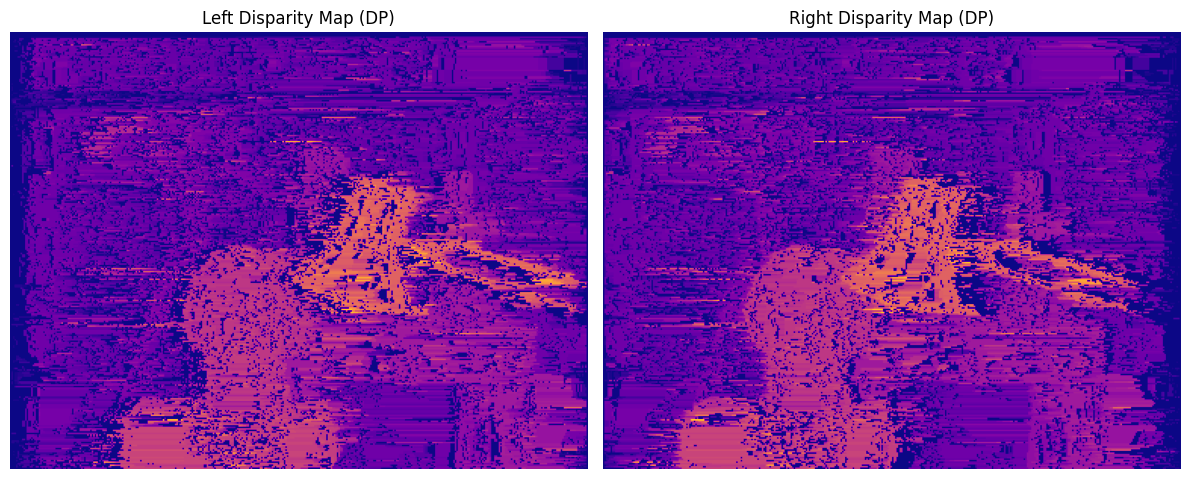

In [4]:
Il = np.array(Image.open("stereo_materials/l1.png").convert("L"), dtype=np.float32)
Ir = np.array(Image.open("stereo_materials/r1.png").convert("L"), dtype=np.float32)

disp_left, disp_right = compute_disparity_dp(Il, Ir, sigma=2, c0=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(disp_left,  cmap="plasma")
axes[0].set_title("Left Disparity Map (DP)")
axes[0].axis("off")
axes[1].imshow(disp_right, cmap="plasma")
axes[1].set_title("Right Disparity Map (DP)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("disparity_dp.png", dpi=150)
plt.show()

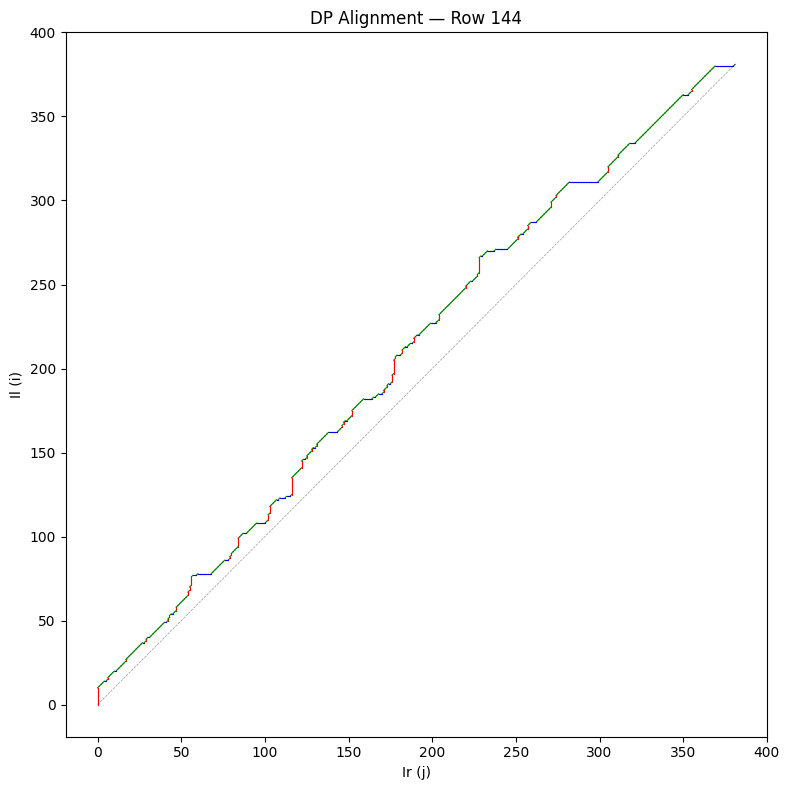

In [5]:
plot_alignment(Il, Ir, row=None, sigma=2, c0=1)

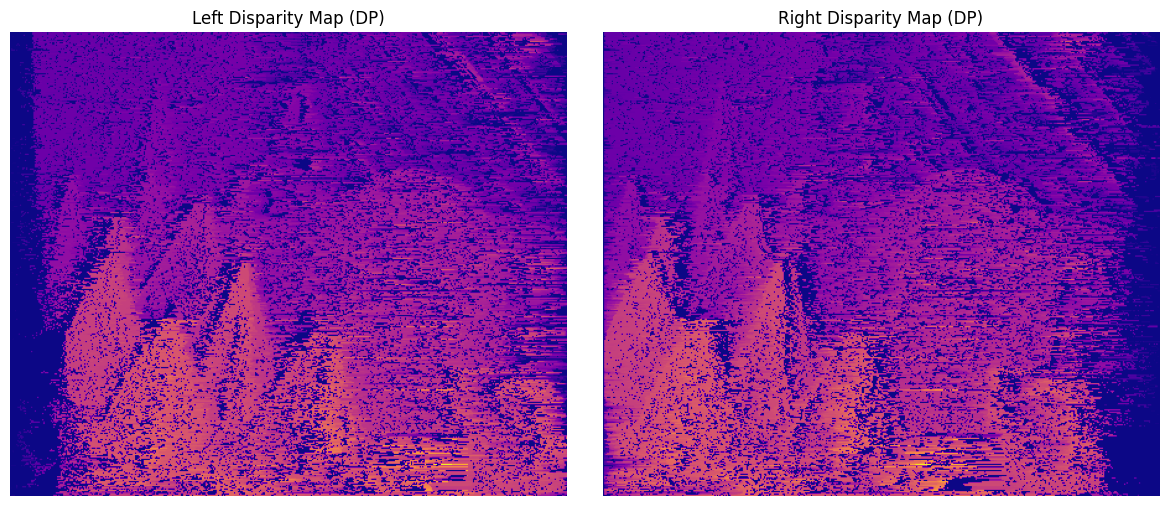

In [6]:

# Load images (replace with your actual image paths)
Il = np.array(Image.open("stereo_materials/l2.png").convert("L"), dtype=np.float32)
Ir = np.array(Image.open("stereo_materials/r2.png").convert("L"), dtype=np.float32)

disp_left, disp_right = compute_disparity_dp(Il, Ir, sigma=2, c0=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(disp_left,  cmap="plasma")
axes[0].set_title("Left Disparity Map (DP)")
axes[0].axis("off")
axes[1].imshow(disp_right, cmap="plasma")
axes[1].set_title("Right Disparity Map (DP)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("disparity_dp.png", dpi=150)
plt.show()

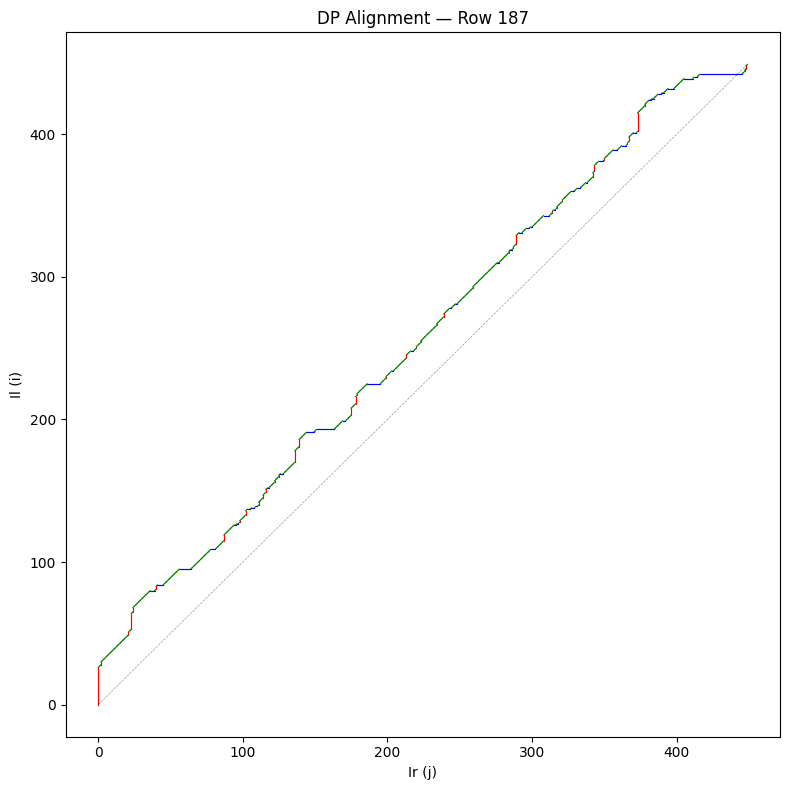

In [7]:
plot_alignment(Il, Ir, row=None, sigma=2, c0=1)

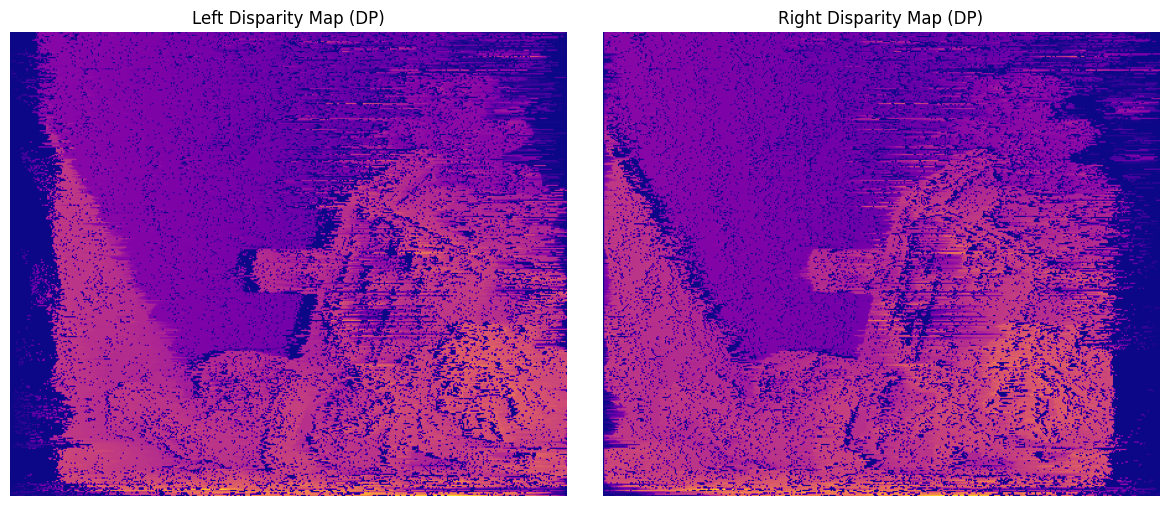

In [8]:
Il = np.array(Image.open("stereo_materials/l3.png").convert("L"), dtype=np.float32)
Ir = np.array(Image.open("stereo_materials/r3.png").convert("L"), dtype=np.float32)

disp_left, disp_right = compute_disparity_dp(Il, Ir, sigma=2, c0=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(disp_left,  cmap="plasma")
axes[0].set_title("Left Disparity Map (DP)")
axes[0].axis("off")
axes[1].imshow(disp_right, cmap="plasma")
axes[1].set_title("Right Disparity Map (DP)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("disparity_dp.png", dpi=150)
plt.show()

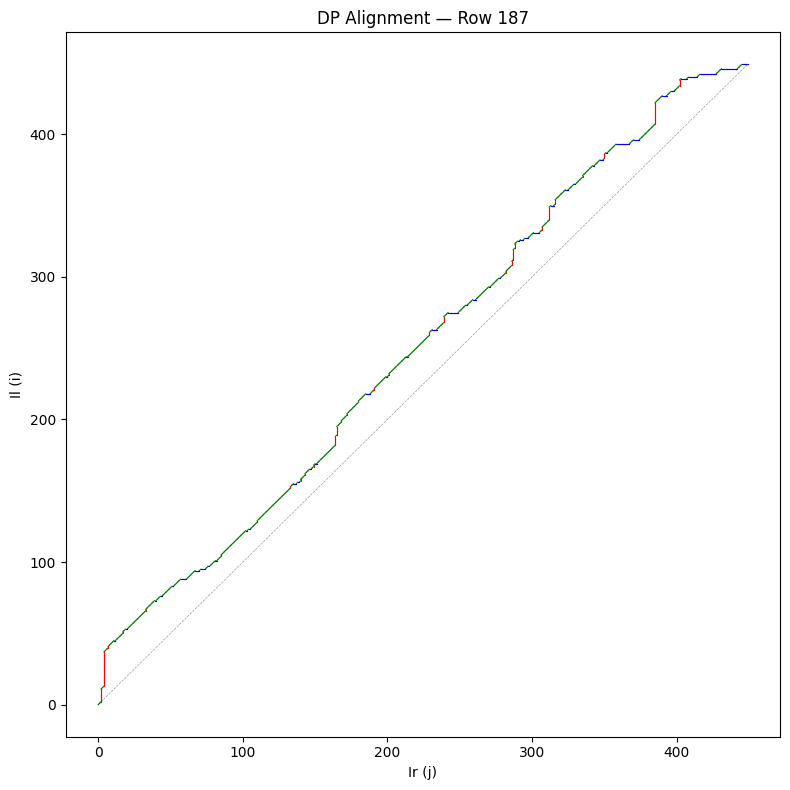

In [9]:
plot_alignment(Il, Ir, row=None, sigma=2, c0=1)